# 📉 **APE 7: Distribuciones Muestrales y Teorema del Límite Central (TLC)**
## **Simulación Estocástica y Técnicas de Remuestreo** 🧬

---

### 👥 **Grupo G - Estudiantes:**
* Emerson Sebastian Chamba Galarza
* Matias Sebastian Labanda Pineda
* Lenin Fabricio Macas Cabrera
* Pilar Valentina Naranjo Quizhpe
* Mateo Sebastian Pucha Carrera

---

### 🎯 **2. Objetivo(s) de la Práctica**

* **Demostrar computacionalmente** el Teorema del Límite Central (TLC) extrayendo múltiples muestras aleatorias de distribuciones poblacionales marcadamente asimétricas (no normales) mediante programación en Python.
*  **Aplicar técnicas de remuestreo** (*bootstrapping* básico) sobre el conjunto de datos regional del Proyecto Integrador, observando el comportamiento de las medias de submuestras empíricas (**ABP**).
*  **Investigar el impacto** del tamaño de la muestra ($n$) en la reducción del Error Estándar de la Media ($SE$), validando matemáticamente la ley de los grandes números (**ABI**).


## 📐 **Tarea 1: Generación de una Población Asimétrica (No Normal)** 📊

--- Parámetros Poblacionales Reales ---
Media (μ): 1.9919
Desviación Estándar (σ): 1.9859


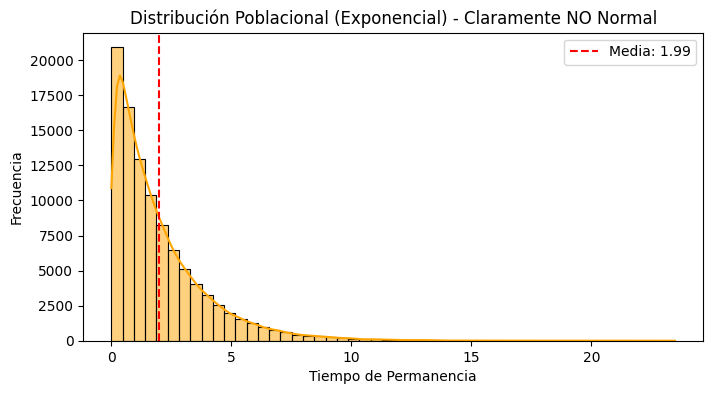

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creación de la Población "Universo" (Altamente asimétrica)
np.random.seed(42)
poblacion_exponencial = np.random.exponential(scale=2.0, size=100000)

mu_pob = np.mean(poblacion_exponencial)
sigma_pob = np.std(poblacion_exponencial)

print(f"--- Parámetros Poblacionales Reales ---")
print(f"Media (μ): {mu_pob:.4f}")
print(f"Desviación Estándar (σ): {sigma_pob:.4f}")

# Visualización de la Población Original
plt.figure(figsize=(8, 4))
sns.histplot(poblacion_exponencial, bins=50, kde=True, color='orange')
plt.title("Distribución Poblacional (Exponencial) - Claramente NO Normal")
plt.xlabel("Tiempo de Permanencia")
plt.ylabel("Frecuencia")
plt.axvline(mu_pob, color='red', linestyle='dashed', label=f'Media: {mu_pob:.2f}')
plt.legend()
plt.show()

## 🌀 **Tarea 2: Simulación Estocástica del Teorema del Límite Central**

--- Estadísticos de las Medias Muestrales (n=30) ---
Media de las Medias Muestrales (E[X]): 1.9803
Error Estándar Empírico (σ_x): 0.3711
Error Estándar Teórico (σ/√n): 0.3626


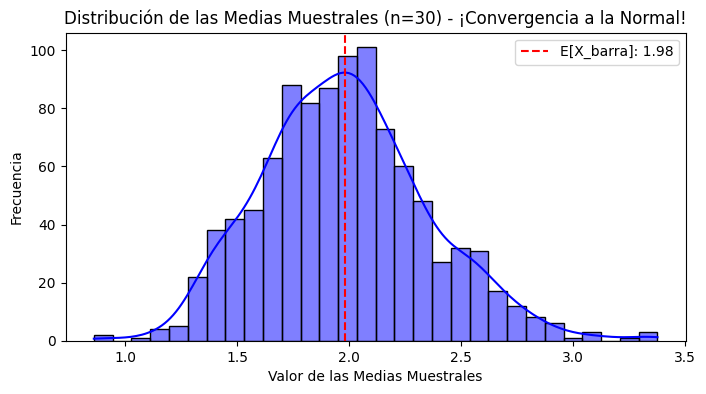

In [ ]:
tamaño_muestra = 30 # n
numero_muestras = 1000 # k

# Array para almacenar las medias de cada muestra
medias_muestrales = []

# Bucle de Monte Carlo simple
for _ in range(numero_muestras):
    # Extraer muestra aleatoria sin reemplazo desde la población de la Tarea 1
    muestra = np.random.choice(poblacion_exponencial, size=tamaño_muestra, replace=False)
    # Calcular y guardar la media de esta muestra específica
    medias_muestrales.append(np.mean(muestra))

# Estadísticos de la Distribución Muestral
media_de_medias = np.mean(medias_muestrales)
error_estandar_empirico = np.std(medias_muestrales)
error_estandar_teorico = sigma_pob / np.sqrt(tamaño_muestra)

print(f"--- Estadísticos de las Medias Muestrales (n={tamaño_muestra}) ---")
print(f"Media de las Medias Muestrales (E[X]): {media_de_medias:.4f}")
print(f"Error Estándar Empírico (σ_x): {error_estandar_empirico:.4f}")
print(f"Error Estándar Teórico (σ/√n): {error_estandar_teorico:.4f}")

# Visualización de la convergencia a la Normal
plt.figure(figsize=(8, 4))
sns.histplot(medias_muestrales, bins=30, kde=True, color='blue')
plt.title(f"Distribución de las Medias Muestrales (n={tamaño_muestra}) - ¡Convergencia a la Normal!")
plt.xlabel("Valor de las Medias Muestrales")
plt.ylabel("Frecuencia")
plt.axvline(media_de_medias, color='red', linestyle='dashed', label=f'E[X_barra]: {media_de_medias:.2f}')
plt.legend()
plt.show()

## 🥾 **Tarea 3: Hito del Proyecto - Aplicación de Remuestreo al Dataset Regional (ABP)** 📈

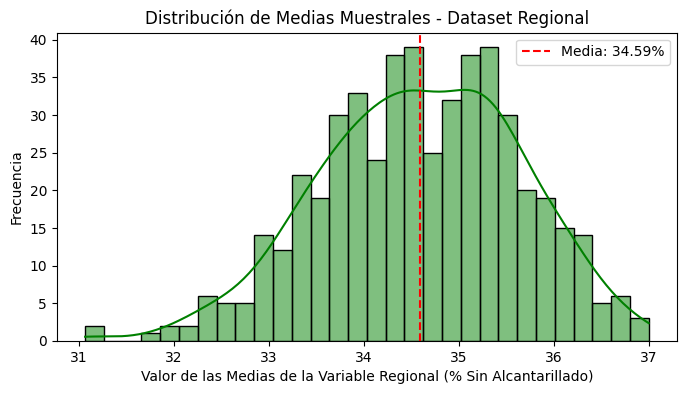

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset regional
df = pd.read_csv('/content/datos_loja2.csv')

df['Porcentaje_Sin_Alcantarillado'] = (df['Sin_Alcantarillado'] / df['Viviendas']) * 100
columna_datos = df['Porcentaje_Sin_Alcantarillado'].dropna()

# Parámetros solicitados
tamaño_muestra_abp = 40 # n = 40
numero_muestras_abp = 500 # k = 500

# Array para guardar las medias del remuestreo
medias_regional = []

# 3. Bucle adaptado para extraer muestras del DataFrame
for _ in range(numero_muestras_abp):
    # Extrae una submuestra aleatoria con reemplazo de tu variable
    muestra_rep = columna_datos.sample(n=tamaño_muestra_abp, replace=True)
    medias_regional.append(muestra_rep.mean())

# 4. Graficar el histograma de las medias obtenidas
plt.figure(figsize=(8, 4))
sns.histplot(medias_regional, bins=30, kde=True, color='green') # Usamos verde para diferenciar
plt.title("Distribución de Medias Muestrales - Dataset Regional")
plt.xlabel("Valor de las Medias de la Variable Regional (% Sin Alcantarillado)")
plt.ylabel("Frecuencia")

# Línea de la media de medias
media_final_abp = np.mean(medias_regional)
plt.axvline(media_final_abp, color='red', linestyle='dashed', label=f'Media: {media_final_abp:.2f}%')
plt.legend()
plt.show()

### 🥾  **Justificación del Impacto del Teorema del Límite Central**

La variable `Porcentaje_Sin_Alcantarillado` en la provincia de Loja presenta una distribución asimétrica y no normal, característica común en indicadores relacionados con carencias de servicios básicos. Debido a ello, la aplicación directa de métodos estadísticos paramétricos puede resultar limitada.

Sin embargo, mediante *bootstrapping* con 500 iteraciones y muestras de tamaño $n = 40$, la distribución de las medias muestrales adquiere una forma aproximadamente normal. Este resultado evidencia el cumplimiento del **Teorema del Límite Central (TLC)**, el cual establece que las medias muestrales tienden a seguir una distribución normal aun cuando los datos originales no lo hagan.

Como consecuencia, es posible aplicar técnicas de inferencia estadística, tales como:
* La construcción de intervalos de confianza.
* La estimación de márgenes de error precisos.
* El análisis del comportamiento promedio del indicador.

Esto proporciona una base estadística confiable para apoyar la planificación de obras de saneamiento y la toma de decisiones relacionadas con la asignación de recursos públicos en la provincia de Loja.

## 🧪 **Tarea 4: ABI - Análisis del Error Estándar y la Ley de los Grandes Números** 🔬

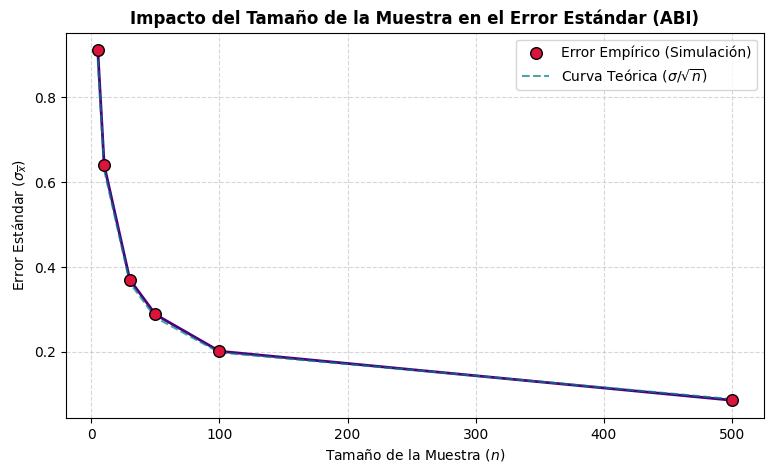

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# RED DE SEGURIDAD: Si reiniciaste el entorno y no encuentra las variables de la Tarea 1, las recreamos aquí
if 'poblacion_exponencial' not in locals():
    np.random.seed(42)
    poblacion_exponencial = np.random.exponential(scale=2.0, size=100000)
    sigma_pob = np.std(poblacion_exponencial)

# 1. Lista de diferentes tamaños de muestra solicitados
tamanos_n = [5, 10, 30, 50, 100, 500]
errores_empiricos = []
errores_teoricos = []
k_simulacion = 1000  # Número de muestras por cada tamaño n

# 2. Bucle iterando sobre la lista de tamaños de muestra
for n in tamanos_n:
    medias_locales = []
    for _ in range(k_simulacion):
        # Extraemos submuestras aleatorias de la población exponencial
        muestra_local = np.random.choice(poblacion_exponencial, size=n, replace=False)
        medias_locales.append(np.mean(muestra_local))

    # Guardar el error estándar empírico (desviación estándar de las medias resultantes)
    errores_empiricos.append(np.std(medias_locales))
    # Guardar el error estándar teórico para comparar (sigma / sqrt(n))
    errores_teoricos.append(sigma_pob / np.sqrt(n))

# 3. Generar el gráfico de líneas tipo scatter plot conectado
plt.figure(figsize=(9, 5))
plt.scatter(tamanos_n, errores_empiricos, color='crimson', edgecolor='black', s=70, zorder=5, label='Error Empírico (Simulación)')
plt.plot(tamanos_n, errores_empiricos, linestyle='-', color='indigo', linewidth=2)

# Agregamos 'r' antes de las comillas para evitar el SyntaxWarning de LaTeX
plt.plot(tamanos_n, errores_teoricos, linestyle='--', color='teal', alpha=0.7, label=r'Curva Teórica ($\sigma / \sqrt{n}$)')

plt.title("Impacto del Tamaño de la Muestra en el Error Estándar (ABI)", fontsize=12, fontweight='bold')
plt.xlabel("Tamaño de la Muestra ($n$)", fontsize=10)
plt.ylabel(r"Error Estándar ($\sigma_{\overline{x}}$)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

## ❓ **7. Preguntas de Control** 📝

---

✨ **1. Basado en la Tarea 1 y 2, ¿por qué el Teorema del Límite Central es considerado el puente matemático fundamental entre la probabilidad descriptiva y la inferencia estadística?**

El Teorema del Límite Central (TLC) es considerado el puente matemático fundamental entre la probabilidad descriptiva y la inferencia estadística porque permite pasar del comportamiento de una población a la realización de conclusiones sobre ella a partir de muestras.

En la Tarea 1, la población seguía una distribución exponencial claramente no normal, con una fuerte asimetría hacia la derecha. Esto muestra la parte descriptiva de la probabilidad: conocer cómo se distribuyen los datos reales de una población.

En la Tarea 2, al tomar múltiples muestras de tamaño n=30 y calcular sus medias, se observó que la distribución de las medias muestrales se aproximó a una distribución normal, aun cuando la población original no era normal. Además, la media de las medias muestrales (≈1.98) fue muy cercana a la media poblacional (≈1.99), y el error estándar empírico fue similar al teórico (σ/
n).

El TLC establece precisamente que, para muestras suficientemente grandes, la distribución de las medias muestrales tiende a ser normal con media μ y desviación estándar σ/n.
Gracias a esta propiedad, podemos utilizar modelos normales para estimar parámetros poblacionales, construir intervalos de confianza y realizar pruebas de hipótesis.

Por ello, el TLC conecta la descripción probabilística de una población con las herramientas de la inferencia estadística, haciendo posible extraer conclusiones confiables sobre una población a partir de información muestral.

---

✨ **2. Demuestre con los resultados impresos en su consola de la Tarea 2, cómo se cumple la propiedad matemática fundamental de las distribuciones muestrales: $E[\bar{X}] = \mu$.**

La propiedad E[Xˉ
]=μ establece que el valor esperado de la media muestral es igual a la media de la población. En los resultados obtenidos, la media poblacional fue μ=1.9919 y la media de las medias muestrales fue E[
X
ˉ
]=1.9803. Como ambos valores son muy cercanos, se verifica que las medias calculadas a partir de múltiples muestras se concentran alrededor de la media real de la población. La pequeña diferencia observada se debe a la variabilidad natural del muestreo, por lo que los resultados confirman experimentalmente que la media muestral es un estimador insesgado de la media poblacional.

---

✨ **3. En la Tarea 4, al graficar la curva del Error Estándar frente a $n$, ¿por qué la curva no desciende de forma lineal? Si usted como ingeniero requiere reducir el error estándar a la mitad, ¿cuántas veces debe incrementar el tamaño de la muestra?**

* **¿Por qué la curva no desciende de forma lineal?:**
  La curva no presenta un comportamiento lineal porque el Error Estándar de la media es inversamente proporcional a la raíz cuadrada del tamaño de la muestra. Esto genera una relación no lineal entre ambas variables. Cuando el tamaño de la muestra es pequeño, aumentar $n$ produce una reducción considerable del error estándar; sin embargo, a medida que $n$ crece, el beneficio de añadir más observaciones es cada vez menor. Por ello, la curva desciende rápidamente al inicio y luego se aplana gradualmente, aproximándose a cero sin alcanzarlo (comportamiento asintótico).

* **¿Cuántas veces se debe incrementar el tamaño de la muestra para reducir el error estándar a la mitad?:**
  Para reducir el error estándar a la mitad es necesario **cuadriplicar (multiplicar por 4)** el tamaño de la muestra. Esto se demuestra algebraicamente al sustituir $4n$ en la fórmula fundamental:

  $$\sigma_{\bar{x},\text{nuevo}} = \frac{\sigma}{\sqrt{4n}} = \frac{\sigma}{2\sqrt{n}} = \frac{1}{2}\left(\frac{\sigma}{\sqrt{n}}\right)$$

  Por lo tanto, para obtener un error estándar dos veces menor se requiere una muestra cuatro veces mayor. Este resultado evidencia claramente los **rendimientos decrecientes del muestreo**: cada reducción adicional del error exige incrementos cada vez más grandes en el tamaño de la muestra, impactando directamente en los costos y la logística de la investigación.

---

✨ **4. Históricamente, en estadística clásica se establece la regla de oro de $n \geq 30$ para asumir normalidad. Si la población regional que usted analizó en la Tarea 3 tiene una asimetría extrema (ej. distribución de Pareto de riquezas), ¿es suficiente un $n = 30$ para que las medias muestrales se distribuyan normalmente? Justifique.**


**No necesariamente.** La regla empírica de $n \ge 30$ es una guía generalizada que suele funcionar de manera óptima cuando la población de origen presenta una asimetría leve o moderada. Sin embargo, cuando la distribución original es extremadamente asimétrica (como una distribución de Pareto), dicho tamaño muestral puede no ser suficiente para que la distribución de las medias muestrales adopte una forma aproximadamente normal.

**Justificación teórica y práctica:**

La velocidad de convergencia establecida por el **Teorema del Límite Central (TLC)** depende directamente de la forma de la distribución poblacional original. En distribuciones altamente asimétricas y con presencia de colas pesadas, una muestra pequeña puede verse fuertemente influenciada por observaciones atípicas, generando medias muestrales alejadas del comportamiento normal esperado.

Si seleccionamos muestras de apenas $n = 30$:
* **Alta influencia de valores extremos:** Una sola observación atípica (*outlier*) tendrá un peso desproporcionado en la muestra, llegando a afectar y desplazar considerablemente el valor de la media muestral calculada.
* **Persistencia del sesgo:** Al promediar y graficar las múltiples muestras, la distribución de las medias resultantes puede conservar una marcada asimetría y colas largas, alejándose de la forma simétrica y acampanada de Gauss.

Por lo tanto, aunque el Teorema del Límite Central continúa siendo válido, la convergencia hacia la normalidad en poblaciones hiper-asimétricas requiere tamaños muestrales significativamente mayores (comúnmente $n \ge 100$, $n \ge 200$ o más). En conclusión, la regla de $n \ge 30$ no debe considerarse una garantía absoluta de normalidad; su validez real depende de las características de la población de origen y el ingeniero debe evaluarla críticamente junto con el grado de asimetría presente en los datos.

---

✨ **5. Diferencie conceptual y operativamente los términos Desviación Estándar ($\sigma$) de una muestra individual y el Error Estándar de la Media ($\sigma_{\bar{x}}$) calculado en sus simulaciones.**

La desviación estándar poblacional (σ) o muestral (s) mide la dispersión de los datos respecto a su media. Indica qué tan diferentes son las observaciones entre sí dentro de una población o muestra. Se calcula directamente a partir de los datos observados en una sola matriz o vector mediante el uso de funciones directas (por ejemplo, `np.std(datos_crudos)`).

Por su parte, el **Error Estándar de la Media** ($\sigma_{\bar{x}}$) mide la variabilidad de las medias muestrales y representa la precisión con la que una muestra estima la media poblacional. No describe la dispersión de los individuos, sino la incertidumbre asociada al estimador de la media. Operativamente en la simulación, equivale a calcular la desviación estándar del conjunto de promedios recopilados (`np.std(medias_muestrales)`).

La diferencia principal es que la desviación estándar analiza la variabilidad de las observaciones, mientras que el error estándar analiza la variabilidad de los promedios obtenidos mediante muestreo. Además, el error estándar disminuye cuando aumenta el tamaño de la muestra, según:

$$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$$

Por ello, la recolección de muestras más grandes produce estimaciones significativamente más precisas y compactas en torno a la verdadera media poblacional.


### 📚 **Referencias Bibliográficas**
---

**[1]** OpenStax, "1.1 Definiciones de estadística, probabilidad y términos clave," *Introducción a la estadística empresarial*, 2022. [En línea]. Disponible en: https://openstax.org/books/introducci%C3%B3n-estad%C3%ADstica-empresarial/pages/1-1-definiciones-de-estadistica-probabilidad-y-terminos-clave.

**[2]** J. S. Castro, "Teorema Central del Límite," *Scribd*, 2023. [En línea]. Disponible en: https://es.scribd.com/document/647778363/TEOREMA-CENTRAL-DEL-LIMITE.

**[3]** DataCamp, "Teorema del Límite Central (TLC): Una guía introductoria," *DataCamp Tutorials*, 2024. [En línea]. Disponible en: https://www.datacamp.com/es/tutorial/central-limit-theorem.

**[4]** Universidad del Valle de México, "Teorema del Límite Central y sus aplicaciones más importantes," *StuDocu*, 2022. [En línea]. Disponible en: https://www.studocu.com/es-mx/document/universidad-del-valle-de-mexico/estadistica-inferencial/teorema-del-limite-central-y-sus-aplicaciones-mas-importantes/20643194.